# 05b — OT/ICS Extended Evaluation: Two Pitfalls, Two Protocols, Calibration, and Alarm Filtering

Companion to **05_ot_ics_paper_evaluation.ipynb**. Reproduces the extended experiments of the
paper *"Label Leakage in ICS Anomaly Detection: A Reproducible Re-Evaluation of an Autoencoder
Detector on the HAI Testbed"*:

1. **Pitfall 1 — label leakage, quantified exactly.** The original leaked model (59 sensors +
   the 4 attack-label columns as inputs) is preserved in `data/processed/` and evaluated directly:
   ROC AUC = 1.000000 exactly. Channel-level attribution shows the contamination is *model-deep* —
   the sensor channels' errors alone still score AUC 1.0 — so a leaked model cannot be repaired at
   scoring time.
2. **Pitfall 2 — cross-session normal contamination.** The original pipeline pooled normal rows
   from all four HAI files before splitting (~80% of test-file normals seen in training). A strict
   session-disjoint retrain of the identical architecture scores AUC 0.869 vs the pooled 0.929.
3. **Nominal vs realized FPR** — percentile-threshold calibration under session shift.
4. **Temporal alarm aggregation** — minimum-run filtering for analyst triage.
5. **Per-process AUC** for autoencoder / PCA / Isolation Forest.
6. **Block-bootstrap 95% CIs** for the headline AUC/AP.

Requires `data/raw/{train1,train2,test1,test2}.csv` (HAI 21.03) and the model artifacts in
`data/processed/`. All randomness is seeded; numbers match the paper.

In [1]:
import ast, json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().parent if (Path.cwd() / '..' / 'data').resolve().exists() else Path.cwd()
DATA_RAW, DATA_PROC = ROOT / 'data' / 'raw', ROOT / 'data' / 'processed'
SEED, EPOCHS, BATCH, LR, BLOCK, N_BOOT = 42, 50, 256, 1e-3, 3600, 500
LABEL_COLS = ['attack', 'attack_P1', 'attack_P2', 'attack_P3']

class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 128), nn.ReLU(),
                                     nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, encoding_dim))
        self.decoder = nn.Sequential(nn.Linear(encoding_dim, 64), nn.ReLU(),
                                     nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, input_dim))
    def forward(self, x):
        return self.decoder(self.encoder(x))

def ae_errors(model, Xs, batch=8192):
    errs = np.empty(len(Xs))
    model.eval()
    with torch.no_grad():
        for i in range(0, len(Xs), batch):
            xb = torch.tensor(Xs[i:i+batch], dtype=torch.float32)
            errs[i:i+batch] = torch.mean((model(xb) - xb) ** 2, dim=1).numpy()
    return errs

def op_metrics(y, pred):
    tp = int(((pred == 1) & (y == 1)).sum()); fp = int(((pred == 1) & (y == 0)).sum())
    fn = int(((pred == 0) & (y == 1)).sum()); tn = int(((pred == 0) & (y == 0)).sum())
    rec = tp / (tp + fn) if tp + fn else 0.0
    prec = tp / (tp + fp) if tp + fp else 0.0
    fpr = fp / (fp + tn) if fp + tn else 0.0
    return rec, prec, fpr

def segments(arr):
    out, i, n = [], 0, len(arr)
    while i < n:
        if arr[i] == 1:
            j = i
            while j < n and arr[j] == 1: j += 1
            out.append((i, j)); i = j
        else: i += 1
    return out

def min_run_filter(pred, k):
    if k <= 1: return pred
    out = pred.copy()
    for s, e in segments(pred):
        if e - s < k: out[s:e] = 0
    return out

meta = dict(l.partition('=')[::2] for l in (DATA_PROC / 'autoencoder_hai_meta.txt').read_text().splitlines())
feature_cols = ast.literal_eval(meta['feature_cols'])
threshold = float(meta['threshold'])
print(f'{len(feature_cols)} sensor features, deployed threshold {threshold}')

59 sensor features, deployed threshold 0.009223


## Load the canonical test files (test1 + test2) and check the label structure

In [2]:
ov = {c: pl.Float64 for c in feature_cols}
t1 = pl.read_csv(DATA_RAW / 'test1.csv', separator=';', columns=feature_cols + LABEL_COLS, schema_overrides=ov)
t2 = pl.read_csv(DATA_RAW / 'test2.csv', separator=';', columns=feature_cols + LABEL_COLS, schema_overrides=ov)
Xtest = np.vstack([t1.select(feature_cols).to_numpy(), t2.select(feature_cols).to_numpy()]).astype(np.float32)
Xtest_leak = np.vstack([t1.select(feature_cols + LABEL_COLS).to_numpy(),
                        t2.select(feature_cols + LABEL_COLS).to_numpy()]).astype(np.float32)
y = np.concatenate([t1['attack'].to_numpy(), t2['attack'].to_numpy()]).astype(int)
p1, p2, p3 = (np.concatenate([t1[c].to_numpy(), t2[c].to_numpy()]).astype(int)
              for c in ('attack_P1', 'attack_P2', 'attack_P3'))
n1 = len(t1); del t1, t2
print(f'test rows={len(y):,}  attacks={y.sum():,} ({100*y.mean():.2f}%)')
print(f'per-process label sum P1+P2+P3 = {p1.sum()+p2.sum()+p3.sum():,} '
      f'(> {y.sum():,} because {((p1+p2+p3)>1).sum():,} rows carry multiple process labels)')
print(f'attack rows with no process label: {((y==1)&(p1+p2+p3==0)).sum()}  (no attack_P4 column exists)')

test rows=444,600  attacks=17,527 (3.94%)
per-process label sum P1+P2+P3 = 22,696 (> 17,527 because 5,169 rows carry multiple process labels)
attack rows with no process label: 0  (no attack_P4 column exists)


## Pitfall 1 — the leaked model, evaluated exactly

The original artifact (63 inputs) was preserved as `autoencoder_hai_leaky_backup.pth`. We evaluate
it as-is, then attribute the perfect score at channel level.

LEAKED model:  ROC AUC = 1.000000   AP = 1.000000
  label-channels-only AUC  = 1.000000


  sensor-channels-only AUC = 1.000000   <- model-deep contamination
  label-channel MSE: attacks 50.1  vs normals 0.0001426


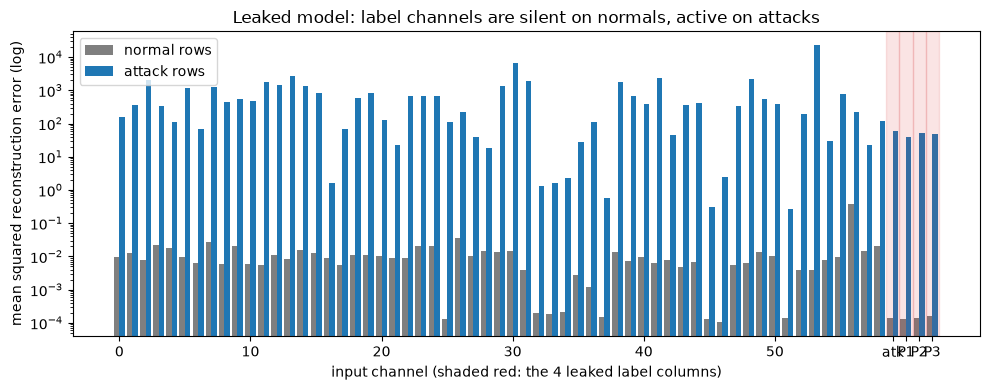

In [3]:
scaler_lk = joblib.load(DATA_PROC / 'scaler_hai_leaky_backup.pkl')
model_lk = Autoencoder(63)
model_lk.load_state_dict(torch.load(DATA_PROC / 'autoencoder_hai_leaky_backup.pth', map_location='cpu'))
Xlk = scaler_lk.transform(Xtest_leak).astype(np.float32)

E = np.empty_like(Xlk, dtype=np.float64)   # per-channel squared errors
model_lk.eval()
with torch.no_grad():
    for i in range(0, len(Xlk), 8192):
        xb = torch.tensor(Xlk[i:i+8192], dtype=torch.float32)
        E[i:i+8192] = ((model_lk(xb) - xb) ** 2).numpy()
err_lk = E.mean(axis=1)

print(f'LEAKED model:  ROC AUC = {roc_auc_score(y, err_lk):.6f}   AP = {average_precision_score(y, err_lk):.6f}')
print(f'  label-channels-only AUC  = {roc_auc_score(y, E[:, 59:].mean(axis=1)):.6f}')
print(f'  sensor-channels-only AUC = {roc_auc_score(y, E[:, :59].mean(axis=1)):.6f}   <- model-deep contamination')
print(f'  label-channel MSE: attacks {E[y==1, 59:].mean():.4g}  vs normals {E[y==0, 59:].mean():.4g}')

m_att, m_nor = E[y == 1].mean(axis=0), E[y == 0].mean(axis=0)
x = np.arange(63); w = 0.42
plt.figure(figsize=(10, 4))
plt.bar(x - w/2, m_nor, width=w, label='normal rows', color='#7f7f7f')
plt.bar(x + w/2, m_att, width=w, label='attack rows', color='#1f77b4')
for i in range(59, 63):
    plt.axvspan(i - 0.5, i + 0.5, color='#d62728', alpha=0.12)
plt.yscale('log')
plt.xticks([0, 10, 20, 30, 40, 50, 59, 60, 61, 62],
           ['0', '10', '20', '30', '40', '50', 'atk', 'P1', 'P2', 'P3'])
plt.xlabel('input channel (shaded red: the 4 leaked label columns)')
plt.ylabel('mean squared reconstruction error (log)')
plt.title('Leaked model: label channels are silent on normals, active on attacks')
plt.legend(); plt.tight_layout(); plt.show()

## Pitfall 2 — cross-session normal contamination, and the strict session-disjoint retrain

The deployed model was trained on normals pooled from **all four** files (so ~80% of test-file
normals were seen in training). Below we train — or load, if the deterministic artifact already
exists — the identical architecture on **training-file normals only** (90% fit / 10% held-out
calibration; seed 42, 50 epochs, batch 256, Adam lr=1e-3).

In [4]:
tr1 = pl.read_csv(DATA_RAW / 'train1.csv', separator=';', columns=feature_cols + ['attack'], schema_overrides=ov)
tr2 = pl.read_csv(DATA_RAW / 'train2.csv', separator=';', columns=feature_cols + ['attack'], schema_overrides=ov)
Xtr = np.vstack([tr1.select(feature_cols).to_numpy(), tr2.select(feature_cols).to_numpy()]).astype(np.float32)
ytr = np.concatenate([tr1['attack'].to_numpy(), tr2['attack'].to_numpy()]).astype(int)
del tr1, tr2
Xtr_norm = Xtr[ytr == 0]
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(Xtr_norm))
n_fit = int(0.9 * len(Xtr_norm))
fit_idx, cal_idx = perm[:n_fit], perm[n_fit:]
print(f'train rows={len(ytr):,}  normals={len(Xtr_norm):,}  fit={n_fit:,}  calibration={len(cal_idx):,}')

strict_pth = DATA_PROC / 'autoencoder_hai_strict.pth'
if strict_pth.exists():
    scaler_st = joblib.load(DATA_PROC / 'scaler_hai_strict.pkl')
    model_st = Autoencoder(59)
    model_st.load_state_dict(torch.load(strict_pth, map_location='cpu'))
    print('loaded saved strict artifact (delete it to retrain from scratch; training is seeded/deterministic)')
else:
    scaler_st = StandardScaler().fit(Xtr_norm[fit_idx])
    Xfit = scaler_st.transform(Xtr_norm[fit_idx]).astype(np.float32)
    torch.manual_seed(SEED)
    model_st = Autoencoder(59)
    opt = torch.optim.Adam(model_st.parameters(), lr=LR)
    lossf = nn.MSELoss()
    t = torch.tensor(Xfit); g = torch.Generator().manual_seed(SEED)
    model_st.train()
    for ep in range(1, EPOCHS + 1):
        pm = torch.randperm(len(t), generator=g); tot = 0.0
        for i in range(0, len(t), BATCH):
            xb = t[pm[i:i+BATCH]]
            opt.zero_grad(); loss = lossf(model_st(xb), xb); loss.backward(); opt.step()
            tot += loss.item() * len(xb)
        if ep in (1, 10, 25, 50): print(f'  epoch {ep}/{EPOCHS} loss={tot/len(t):.6f}')
    torch.save(model_st.state_dict(), strict_pth)
    joblib.dump(scaler_st, DATA_PROC / 'scaler_hai_strict.pkl')

# deployed (pooled-protocol) model
scaler = joblib.load(DATA_PROC / 'scaler_hai.pkl')
model = Autoencoder(59)
model.load_state_dict(torch.load(DATA_PROC / 'autoencoder_hai.pth', map_location='cpu'))
Xtest_s = scaler.transform(Xtest).astype(np.float32)
err = ae_errors(model, Xtest_s)
err_st = ae_errors(model_st, scaler_st.transform(Xtest).astype(np.float32))
cal_err_st = ae_errors(model_st, scaler_st.transform(Xtr_norm[cal_idx]).astype(np.float32))

print('\n=== The honesty ladder (identical test set) ===')
print(f'leaked (63 inputs):            AUC = 1.000000')
print(f'leakage-free, pooled normals:  AUC = {roc_auc_score(y, err):.4f}  AP = {average_precision_score(y, err):.4f}')
print(f'leakage-free, session-disjoint AUC = {roc_auc_score(y, err_st):.4f}  AP = {average_precision_score(y, err_st):.4f}')
for p in (95, 99):
    thr_p = np.percentile(cal_err_st, p)
    rec, prec, fpr = op_metrics(y, (err_st > thr_p).astype(int))
    print(f'strict @ p{p} calibration threshold: recall={rec:.3f} FPR={fpr:.3f} (nominal {100-p}%)')

train rows=550,800  normals=550,024  fit=495,021  calibration=55,003
loaded saved strict artifact (delete it to retrain from scratch; training is seeded/deterministic)



=== The honesty ladder (identical test set) ===
leaked (63 inputs):            AUC = 1.000000


leakage-free, pooled normals:  AUC = 0.9290  AP = 0.7331


leakage-free, session-disjoint AUC = 0.8687  AP = 0.6815
strict @ p95 calibration threshold: recall=0.984 FPR=0.754 (nominal 5%)
strict @ p99 calibration threshold: recall=0.928 FPR=0.534 (nominal 1%)


## Nominal vs realized false-positive rate (deployed model)

Thresholds are calibrated on *held-out same-session* normals (calibration split of the training
files), so the nominal rate is honoured out-of-sample within-session — then measured on the
session-disjoint test normals.

In [5]:
cal_err_dep = ae_errors(model, scaler.transform(Xtr_norm[cal_idx]).astype(np.float32))
print(f'{"pct":>6} {"nominal":>8} {"same-sess":>10} {"test-sess":>10} {"inflation":>10}')
for p in (90, 95, 97.5, 99, 99.9):
    thr_p = np.percentile(cal_err_dep, p)
    same = (cal_err_dep > thr_p).mean()
    real = (err[y == 0] > thr_p).mean()
    print(f'{p:>6} {(100-p)/100:>8.3f} {same:>10.3f} {real:>10.3f} {real/((100-p)/100):>9.1f}x')
same_d = (cal_err_dep > threshold).mean(); real_d = (err[y == 0] > threshold).mean()
print(f'{"deflt":>6} {"-":>8} {same_d:>10.3f} {real_d:>10.3f}')

   pct  nominal  same-sess  test-sess  inflation
    90    0.100      0.100      0.211       2.1x
    95    0.050      0.050      0.144       2.9x
  97.5    0.025      0.025      0.078       3.1x
    99    0.010      0.010      0.040       4.0x
  99.9    0.001      0.001      0.026      26.2x
 deflt        -      0.091      0.201


## Temporal alarm aggregation (minimum-run filtering)

A sample only alarms if it belongs to a run of at least *k* consecutive over-threshold samples.
Segment recall = fraction of the 38 ground-truth attack segments with at least one alarm;
alert episodes = contiguous alarm runs an analyst would triage.

In [6]:
segs = segments(y[:n1]) + [(a + n1, b + n1) for a, b in segments(y[n1:])]
print(f'{len(segs)} ground-truth attack segments')
p99_thr = np.percentile(cal_err_dep, 99)
for name, thr_v in (('default threshold', threshold), ('99th-pct threshold', p99_thr)):
    print(f'--- {name} (MSE {thr_v:.4g}) ---')
    print(f'{"k":>4} {"recall":>8} {"precision":>10} {"FPR":>7} {"seg-recall":>11} {"episodes":>9}')
    for k in (1, 2, 3, 5, 10, 30, 60):
        pred = np.concatenate([min_run_filter((err[:n1] > thr_v).astype(int), k),
                               min_run_filter((err[n1:] > thr_v).astype(int), k)])
        rec, prec, fpr = op_metrics(y, pred)
        seg_rec = np.mean([pred[a:b].any() for a, b in segs])
        eps = len(segments(pred[:n1])) + len(segments(pred[n1:]))
        print(f'{k:>4} {rec:>8.3f} {prec:>10.3f} {fpr:>7.3f} {seg_rec:>11.3f} {eps:>9,}')

38 ground-truth attack segments
--- default threshold (MSE 0.009223) ---
   k   recall  precision     FPR  seg-recall  episodes
   1    0.879      0.152   0.201       1.000     7,946


   2    0.874      0.157   0.192       1.000     4,208


   3    0.870      0.162   0.185       0.974     2,542


   5    0.858      0.168   0.174       0.974     1,111
  10    0.847      0.179   0.160       0.947       247


  30    0.840      0.182   0.154       0.921        93
  60    0.835      0.183   0.153       0.895        72
--- 99th-pct threshold (MSE 0.0605) ---
   k   recall  precision     FPR  seg-recall  episodes
   1    0.726      0.426   0.040       0.895     1,810


   2    0.719      0.435   0.038       0.868       979
   3    0.714      0.441   0.037       0.868       682


   5    0.700      0.452   0.035       0.842       310
  10    0.694      0.464   0.033       0.842       176


  30    0.687      0.487   0.030       0.816        94
  60    0.678      0.501   0.028       0.816        70


## Per-process AUC for all methods (baseline failure modes)

In [7]:
norm_idx = rng.choice(len(Xtr_norm), size=min(100_000, len(Xtr_norm)), replace=False)
norm_s = scaler.transform(Xtr_norm[norm_idx]).astype(np.float32)
pca = PCA(n_components=32, random_state=SEED).fit(norm_s)
pca_err = np.mean((Xtest_s - pca.inverse_transform(pca.transform(Xtest_s))) ** 2, axis=1)
iso = IsolationForest(n_estimators=100, random_state=SEED, n_jobs=-1).fit(norm_s)
iso_score = -iso.score_samples(Xtest_s)
print(f'{"proc":>6} {"n attacks":>10} {"AE":>7} {"PCA":>7} {"IsoF":>7}')
for name, mask in (('P1', p1), ('P2', p2), ('P3', p3)):
    sel = (y == 0) | (mask == 1)
    yy = (mask[sel] == 1).astype(int)
    print(f'{name:>6} {mask.sum():>10,} {roc_auc_score(yy, err[sel]):>7.3f} '
          f'{roc_auc_score(yy, pca_err[sel]):>7.3f} {roc_auc_score(yy, iso_score[sel]):>7.3f}')

  proc  n attacks      AE     PCA    IsoF


    P1     14,890   0.932   0.881   0.806


    P2      6,005   0.979   0.903   0.837


    P3      1,801   0.897   0.725   0.719


## Block-bootstrap 95% CIs (1-hour blocks, resampled within each test split)

In [8]:
rng_b = np.random.default_rng(SEED)
starts1 = np.arange(0, n1 - BLOCK + 1, BLOCK)
starts2 = np.arange(n1, len(y) - BLOCK + 1, BLOCK)
aucs, aps = [], []
for _ in range(N_BOOT):
    idx = np.concatenate([
        np.concatenate([np.arange(s, s + BLOCK) for s in rng_b.choice(starts1, size=len(starts1))]),
        np.concatenate([np.arange(s, s + BLOCK) for s in rng_b.choice(starts2, size=len(starts2))]),
    ])
    yb = y[idx]
    if 0 < yb.sum() < len(yb):
        aucs.append(roc_auc_score(yb, err[idx]))
        aps.append(average_precision_score(yb, err[idx]))
print(f'{len(aucs)} valid resamples')
print(f'AUC = {roc_auc_score(y, err):.3f}   95% CI [{np.percentile(aucs, 2.5):.3f}, {np.percentile(aucs, 97.5):.3f}]')
print(f'AP  = {average_precision_score(y, err):.3f}   95% CI [{np.percentile(aps, 2.5):.3f}, {np.percentile(aps, 97.5):.3f}]')

500 valid resamples
AUC = 0.929   95% CI [0.893, 0.960]
AP  = 0.733   95% CI [0.613, 0.827]


## Summary

| Result | Value |
|---|---|
| Leaked model (59 sensors + 4 label columns) | **AUC 1.000000 exactly**; sensor-channels-only error still AUC 1.0 (model-deep) |
| Leakage-free, pooled-normals protocol | AUC 0.929 (CI 0.893–0.960), AP 0.733 |
| Leakage-free, strict session-disjoint | AUC 0.869, AP 0.682 |
| Percentile calibration under session shift | nominal FPR overshot 2.1×–26× (pooled), up to 53× (strict) |
| Min-run alarm filter, k=10, default threshold | 7,946 → 247 episodes (32×), 36/38 segments still caught |
| Per-process AUC (AE vs PCA vs IF) | baselines fail hardest on P3 (0.897 vs 0.725 / 0.719) |

Full narrative, tables, and methodology are in the accompanying paper; the machine-readable
results live in the paper artifact (`results_ot_ics.json`).